<a href="https://colab.research.google.com/github/juheesun/-/blob/main/%EC%B6%94%EC%B2%9C%EC%8B%9C%EC%8A%A4%ED%85%9C_%EC%9D%B4%EC%9B%83%EA%B8%B0%EB%B0%98_%ED%8F%89%EA%B0%80.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
모델 로드 완료
  최적 알고리즘 : ITEM_MC
  최적 이웃 수  : K = 20

테스트 데이터 로드: 9,430건

최적 K=20로 4개 모델 최종 평가 시작...

      [최종 테스트 결과 (ua.test)]
  알고리즘                             RMSE      MAE
-------------------------------------------------------
  User-based CF                  0.9692   0.7554
  Item-based CF                  1.4385   1.0827
  Item-based CF+MeanCenter       0.9391   0.7372
  User-based CF+SigWeight        0.9678   0.7522
  ★ 학습 단계에서 선정된 최적 모델 (K=20)

      [최종 랭킹 성능 결과 (Top-10, 기준: 4.0점)]
  알고리즘                          Prec@10   Rec@10       F1
----------------------------------------------------------------------
  User-based CF                  0.5855   1.0000   0.7386
  Item-based CF                  0.5855   1.0000   0.7386
  Item-based CF+MeanCenter       0.5855   1.0000   0.7386
  User-based CF+SigWeight        0.5855   1.0000   0.7386


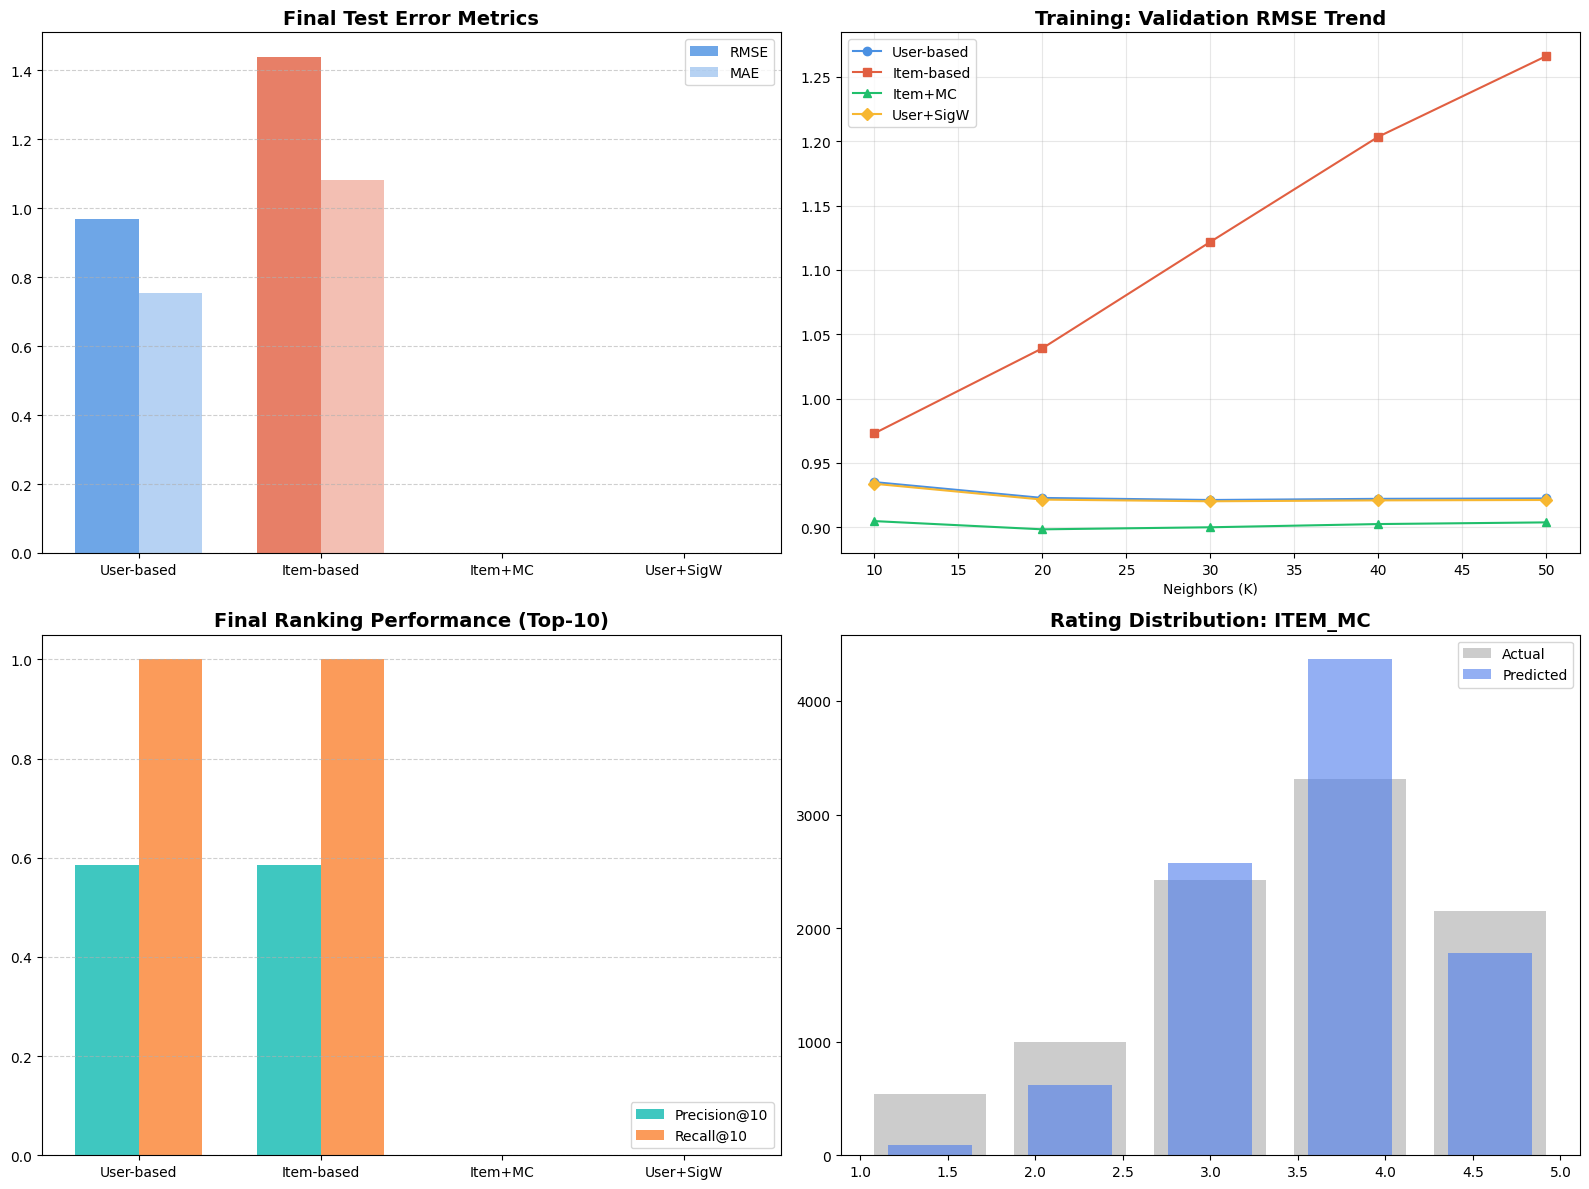


       [ Validation → Test RMSE 성능 변화 ]
  최적 알고리즘   : ITEM_MC
  Validation RMSE : 0.8984
  Test RMSE       : 0.9391
  단위 차이       : +0.0407 (+4.5%)


In [6]:
import pandas as pd
import numpy as np
import pickle
import math
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
from google.colab import drive

# ──────────────────────────────────────────
# 1. 드라이브 마운트 및 모델 로드
# ──────────────────────────────────────────
drive.mount('/content/drive')
base_path = '/content/drive/MyDrive/Recommender_systems/ml-100k/'

with open(base_path + 'model_final_v5.pkl', 'rb') as f:
    model = pickle.load(f)

# 모델 구성 요소 추출
train_matrix              = model['train_matrix']
train_matrix_centered     = model['train_matrix_centered']
train_matrix_item_centered= model['train_matrix_item_centered']
user_sim_df               = model['user_sim']
item_sim_df               = model['item_sim']
item_sim_mc_df            = model['item_sim_mc']
user_sim_weighted_df      = model['user_sim_weighted']
user_mean                 = model['user_mean']
item_mean                 = model['item_mean']
best_k                    = model['best_k']
best_kind                 = model['best_kind']
val_results               = model['val_results']

print(f"모델 로드 완료")
print(f"  최적 알고리즘 : {best_kind.upper()}")
print(f"  최적 이웃 수  : K = {best_k}")

# ──────────────────────────────────────────
# 2. 테스트 데이터 로드
# ──────────────────────────────────────────
test_data = pd.read_csv(base_path + 'ua.test', sep='\t',
                        names=['user_id', 'item_id', 'rating', 'ts'])
print(f"\n테스트 데이터 로드: {len(test_data):,}건")

# ──────────────────────────────────────────
# 3. 예측 함수 4종 (학습 코드와 동일)
# ──────────────────────────────────────────

def predict_user(user_id, item_id, k):
    if user_id not in user_sim_df.index or item_id not in train_matrix.columns:
        return user_mean.get(user_id, 3.0)
    sim_scores = user_sim_df[user_id]
    rated_users = train_matrix[item_id][train_matrix[item_id] > 0].index
    top_k = sim_scores[rated_users].sort_values(ascending=False).head(k)
    if top_k.abs().sum() == 0:
        return user_mean[user_id]
    pred = user_mean[user_id] + (
        np.dot(top_k, train_matrix_centered.loc[top_k.index, item_id])
        / top_k.abs().sum()
    )
    return max(1.0, min(5.0, pred))


def predict_item(user_id, item_id, k):
    if item_id not in item_sim_df.index or user_id not in train_matrix.index:
        return user_mean.get(user_id, 3.0)
    sim_scores = item_sim_df[item_id]
    rated_items = train_matrix.loc[user_id][train_matrix.loc[user_id] > 0].index
    top_k = sim_scores[rated_items].sort_values(ascending=False).head(k)
    if top_k.abs().sum() == 0:
        return user_mean[user_id]
    pred = np.dot(top_k, train_matrix.loc[user_id, top_k.index]) / top_k.abs().sum()
    return max(1.0, min(5.0, pred))


def predict_item_mc(user_id, item_id, k):
    if item_id not in item_sim_mc_df.index or user_id not in train_matrix.index:
        return user_mean.get(user_id, 3.0)
    sim_scores = item_sim_mc_df[item_id]
    rated_items = train_matrix.loc[user_id][train_matrix.loc[user_id] > 0].index
    top_k = sim_scores[rated_items].sort_values(ascending=False).head(k)
    if top_k.abs().sum() == 0:
        return user_mean.get(user_id, 3.0)
    centered_ratings = train_matrix_item_centered.loc[user_id, top_k.index]
    pred = item_mean[item_id] + (
        np.dot(top_k, centered_ratings) / top_k.abs().sum()
    )
    return max(1.0, min(5.0, pred))


def predict_user_weighted(user_id, item_id, k):
    if user_id not in user_sim_weighted_df.index or item_id not in train_matrix.columns:
        return user_mean.get(user_id, 3.0)
    sim_scores = user_sim_weighted_df[user_id]
    rated_users = train_matrix[item_id][train_matrix[item_id] > 0].index
    top_k = sim_scores[rated_users].sort_values(ascending=False).head(k)
    if top_k.abs().sum() == 0:
        return user_mean[user_id]
    pred = user_mean[user_id] + (
        np.dot(top_k, train_matrix_centered.loc[top_k.index, item_id])
        / top_k.abs().sum()
    )
    return max(1.0, min(5.0, pred))


# ──────────────────────────────────────────
# 4. 테스트셋 전체 예측 (4개 모델 모두)
# ──────────────────────────────────────────
print(f"\n최적 K={best_k}로 4개 모델 최종 평가 시작...")

u_preds   = [predict_user(u, i, best_k)          for u, i in zip(test_data['user_id'], test_data['item_id'])]
i_preds   = [predict_item(u, i, best_k)          for u, i in zip(test_data['user_id'], test_data['item_id'])]
imc_preds = [predict_item_mc(u, i, best_k)       for u, i in zip(test_data['user_id'], test_data['item_id'])]
uw_preds  = [predict_user_weighted(u, i, best_k) for u, i in zip(test_data['user_id'], test_data['item_id'])]

# ──────────────────────────────────────────
# 5. 최종 성능 지표 계산
# ──────────────────────────────────────────
def rmse(y, p): return math.sqrt(mean_squared_error(y, p))
def mae(y, p):  return mean_absolute_error(y, p)
y = test_data['rating']

final_results = {
    'User-based CF'              : {'preds': u_preds,   'RMSE': rmse(y, u_preds),   'MAE': mae(y, u_preds)},
    'Item-based CF'              : {'preds': i_preds,   'RMSE': rmse(y, i_preds),   'MAE': mae(y, i_preds)},
    'Item-based CF+MeanCenter'   : {'preds': imc_preds, 'RMSE': rmse(y, imc_preds), 'MAE': mae(y, imc_preds)},
    'User-based CF+SigWeight'    : {'preds': uw_preds,  'RMSE': rmse(y, uw_preds),  'MAE': mae(y, uw_preds)},
}

print("\n" + "="*55)
print("      [최종 테스트 결과 (ua.test)]")
print("="*55)
print(f"  {'알고리즘':<28} {'RMSE':>8} {'MAE':>8}")
print("-"*55)
for name, res in final_results.items():
    marker = " ★" if name.lower().replace(' ','_').replace('-','_').replace('+','_') \
                       .startswith(best_kind.replace('_','')) else ""
    print(f"  {name:<28} {res['RMSE']:>8.4f} {res['MAE']:>8.4f}{marker}")
print("="*55)
print(f"  ★ 학습 단계에서 선정된 최적 모델 (K={best_k})")

def evaluate_ranking_test(test_df, preds, k=10, threshold=4.0):
    """
    테스트셋에 대한 랭킹 지표 계산
    """
    test_copy = test_df.copy()
    test_copy['pred_rating'] = preds

    user_precisions = []
    user_recalls = []

    for user_id in test_copy['user_id'].unique():
        user_data = test_copy[test_copy['user_id'] == user_id]

        # 실제 좋아하는 아이템 (Relevant)
        relevant_items = set(user_data[user_data['rating'] >= threshold]['item_id'])
        if len(relevant_items) == 0: continue

        # 예측 상위 K개 아이템 (Recommended)
        top_k_recommended = set(user_data.sort_values(by='pred_rating', ascending=False).head(k)['item_id'])

        hits = len(relevant_items & top_k_recommended)
        user_precisions.append(hits / k)
        user_recalls.append(hits / len(relevant_items))

    avg_p = np.mean(user_precisions)
    avg_r = np.mean(user_recalls)
    f1 = 2 * (avg_p * avg_r) / (avg_p + avg_r) if (avg_p + avg_r) > 0 else 0
    return avg_p, avg_r, f1

# 4개 모델에 대해 랭킹 지표 일괄 계산
ranking_results = {}
for name, p_list in zip(final_results.keys(), [u_preds, i_preds, imc_preds, uw_preds]):
    p, r, f1 = evaluate_ranking_test(test_data, p_list, k=10)
    ranking_results[name] = {'Precision@10': p, 'Recall@10': r, 'F1-score': f1}

print("\n" + "="*70)
print("      [최종 랭킹 성능 결과 (Top-10, 기준: 4.0점)]")
print("="*70)
print(f"  {'알고리즘':<28} {'Prec@10':>8} {'Rec@10':>8} {'F1':>8}")
print("-"*70)
for name, res in ranking_results.items():
    print(f"  {name:<28} {res['Precision@10']:>8.4f} {res['Recall@10']:>8.4f} {res['F1-score']:>8.4f}")
print("="*70)

# ──────────────────────────────────────────
# 6. 시각화 (4종) - 변수명 및 매핑 완벽 해결 버전
# ──────────────────────────────────────────
display_names = ['User-based', 'Item-based', 'Item+MC', 'User+SigW']
colors = ['#4A90E2', '#E15F41', '#20BF6B', '#F7B731']

def get_val(data_dict, search_term, metric):
    for k in data_dict.keys():
        # 검색어(예: 'Item+MC')와 데이터 키(예: 'Item-based CF+MeanCenter') 비교
        clean_k = k.lower().replace(" ","").replace("-","").replace("+","")
        clean_search = search_term.lower().replace(" ","").replace("-","").replace("+","")
        if clean_search in clean_k or clean_k in clean_search:
            return data_dict[k].get(metric, 0)
    return 0

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
x = np.arange(len(display_names))
width = 0.35

# --- 6-1. 최종 RMSE / MAE (좌상단) ---
rmse_vals = [get_val(final_results, n, 'RMSE') for n in display_names]
mae_vals  = [get_val(final_results, n, 'MAE') for n in display_names]

axes[0, 0].bar(x - width/2, rmse_vals, width, label='RMSE', color=colors, alpha=0.8)
axes[0, 0].bar(x + width/2, mae_vals,  width, label='MAE',  color=colors, alpha=0.4)
axes[0, 0].set_title('Final Test Error Metrics', fontsize=14, fontweight='bold')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(display_names)
axes[0, 0].legend()
axes[0, 0].grid(axis='y', linestyle='--', alpha=0.6)

# --- 6-2. Validation RMSE 추이 (우상단) ---
if 'val_results' in globals() or 'val_results' in locals():
    axes[0, 1].plot(val_results['K'], val_results['User_RMSE'],   marker='o', label='User-based', color=colors[0])
    axes[0, 1].plot(val_results['K'], val_results['Item_RMSE'],   marker='s', label='Item-based', color=colors[1])
    axes[0, 1].plot(val_results['K'], val_results['ItemMC_RMSE'], marker='^', label='Item+MC',     color=colors[2])
    axes[0, 1].plot(val_results['K'], val_results['UserW_RMSE'],  marker='D', label='User+SigW',   color=colors[3])
    axes[0, 1].set_title('Training: Validation RMSE Trend', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Neighbors (K)')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

# --- 6-3. Precision & Recall 비교 (좌하단) ---
# ranking_results에서 지표 추출
p_vals = [get_val(ranking_results, n, 'Precision@10') for n in display_names]
r_vals = [get_val(ranking_results, n, 'Recall@10') for n in display_names]

axes[1, 0].bar(x - width/2, p_vals, width, label='Precision@10', color='#0fb9b1', alpha=0.8)
axes[1, 0].bar(x + width/2, r_vals, width, label='Recall@10', color='#fa8231', alpha=0.8)
axes[1, 0].set_title('Final Ranking Performance (Top-10)', fontsize=14, fontweight='bold')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(display_names)
axes[1, 0].legend(loc='lower right')
axes[1, 0].grid(axis='y', linestyle='--', alpha=0.6)

# --- 6-4. 실제 평점 vs 예측 평점 분포 (우하단) ---
best_preds_map = {'user': u_preds, 'item': i_preds, 'item_mc': imc_preds, 'user_w': uw_preds}
target_preds = best_preds_map.get(best_kind, u_preds)

axes[1, 1].hist(test_data['rating'], bins=5, alpha=0.4, label='Actual', color='gray', rwidth=0.8)
axes[1, 1].hist(target_preds, bins=5, alpha=0.6, label='Predicted', color='#4b7bec', rwidth=0.6)
axes[1, 1].set_title(f'Rating Distribution: {best_kind.upper()}', fontsize=14, fontweight='bold')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# ──────────────────────────────────────────
# 7. Validation vs Test 비교 요약 (안전한 매칭)
# ──────────────────────────────────────────
best_rmse_col_map = {
    'user'   : 'User_RMSE',
    'item'   : 'Item_RMSE',
    'item_mc': 'ItemMC_RMSE',
    'user_w' : 'UserW_RMSE',
}

# 1. Validation Best RMSE
val_best_rmse = val_results[best_rmse_col_map[best_kind]].min()

# 2. Test RMSE 추출 (더 직관적인 매칭)
# best_kind가 'item_mc'라면 final_results에서 'MeanCenter'가 포함된 키를 찾습니다.
test_best_rmse = 0
search_target = best_kind.replace('_', '').lower() # 'itemmc'

for name, metrics in final_results.items():
    clean_name = name.lower().replace(' ', '').replace('-', '').replace('+', '')
    if search_target in clean_name or (search_target == 'itemmc' and 'meancenter' in clean_name):
        test_best_rmse = metrics['RMSE']
        break

print(f"\n" + "="*50)
print(f"       [ Validation → Test RMSE 성능 변화 ]")
print(f"="*50)
print(f"  최적 알고리즘   : {best_kind.upper()}")
print(f"  Validation RMSE : {val_best_rmse:.4f}")
print(f"  Test RMSE       : {test_best_rmse:.4f}")

if test_best_rmse > 0:
    diff = test_best_rmse - val_best_rmse
    perc = (test_best_rmse / val_best_rmse - 1) * 100
    print(f"  단위 차이       : {diff:+.4f} ({perc:+.1f}%)")
else:
    print(f"  단위 차이       : 데이터 매칭 실패 (이름 확인 필요)")
print("="*50)